In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Instagram_with_balanced_captions.csv to Instagram_with_balanced_captions.csv


In [ ]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
df=pd.read_csv("Instagram_with_balanced_captions.csv")

In [ ]:
print(df.isnull().sum())

post_id                     0
caption                     0
account_id                  0
account_type                0
follower_count              0
media_type                  0
content_category            0
traffic_source              0
has_call_to_action          0
post_datetime               0
post_date                   0
post_hour                   0
day_of_week                 0
likes                       0
comments                    0
shares                      0
saves                       0
reach                       0
impressions                 0
engagement_rate             0
followers_gained            0
caption_length              0
hashtags_count              0
performance_bucket_label    0
sentiment_score             0
sentiment                   0
dtype: int64


In [ ]:
df[["post_id","caption"]].head()

,post_id,caption
0,IG0000001,Latest technology: This is awesome! I love the...
1,IG0000002,Training routine: Absolutely brilliant! Everyt...
2,IG0000003,Today's topic: This is awesome! I love the ide...
3,IG0000004,New track: Absolutely brilliant! Everything ab...
4,IG0000005,Technology update: Such a great moment! This m...


In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer=SentimentIntensityAnalyzer()
text=df["caption"].loc[0]
analyzer.polarity_scores(text)

{'neg': 0.0, 'neu': 0.507, 'pos': 0.493, 'compound': 0.8932}

In [ ]:
df["sentiment_score"]=df["caption"].apply(
    lambda x : analyzer.polarity_scores(str(x))["compound"]
)
def get_sentiment(score):
 if score>=0.05:
  return "positive"
 elif score <=-0.05:
  return "negative"
 else:
  return "neutral"
df["sentiment"]=df["sentiment_score"].apply(get_sentiment)
df["sentiment"].value_counts()


,count
sentiment,
positive,13804
negative,8547
neutral,7648


In [ ]:
import pandas as pd
df["post_date"]=pd.to_datetime(df["post_date"])

In [ ]:
daily_sentiment=df.groupby(["post_date","sentiment"]).size().unstack(fill_value=0)
daily_sentiment.columns

Index(['negative', 'neutral', 'positive'], dtype='object', name='sentiment')

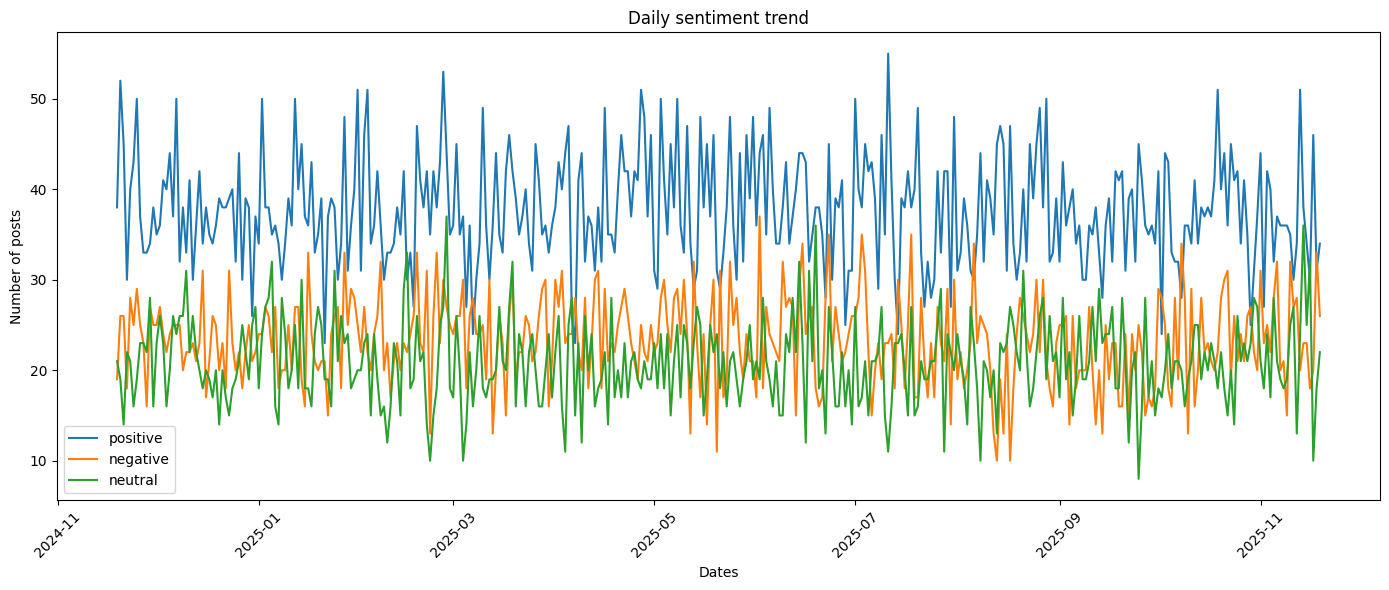

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))

plt.plot(
    daily_sentiment.index,
    daily_sentiment["positive"],
    label="positive"
)

plt.plot(
    daily_sentiment.index,
    daily_sentiment["negative"],
    label="negative"
)

plt.plot(
    daily_sentiment.index,
    daily_sentiment["neutral"],
    label="neutral"

)

plt.xlabel("Dates")
plt.ylabel("Number of posts")
plt.title("Daily sentiment trend")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
weekly_sentiment=df.groupby([pd.Grouper(key="post_date",freq="W"),"sentiment"]).size().unstack(fill_value=0)
weekly_sentiment.head()

sentiment,negative,neutral,positive
post_date,,,
2024-11-24,142,113,248
2024-12-01,170,154,260
2024-12-08,172,161,280
2024-12-15,162,165,254
2024-12-22,150,127,258


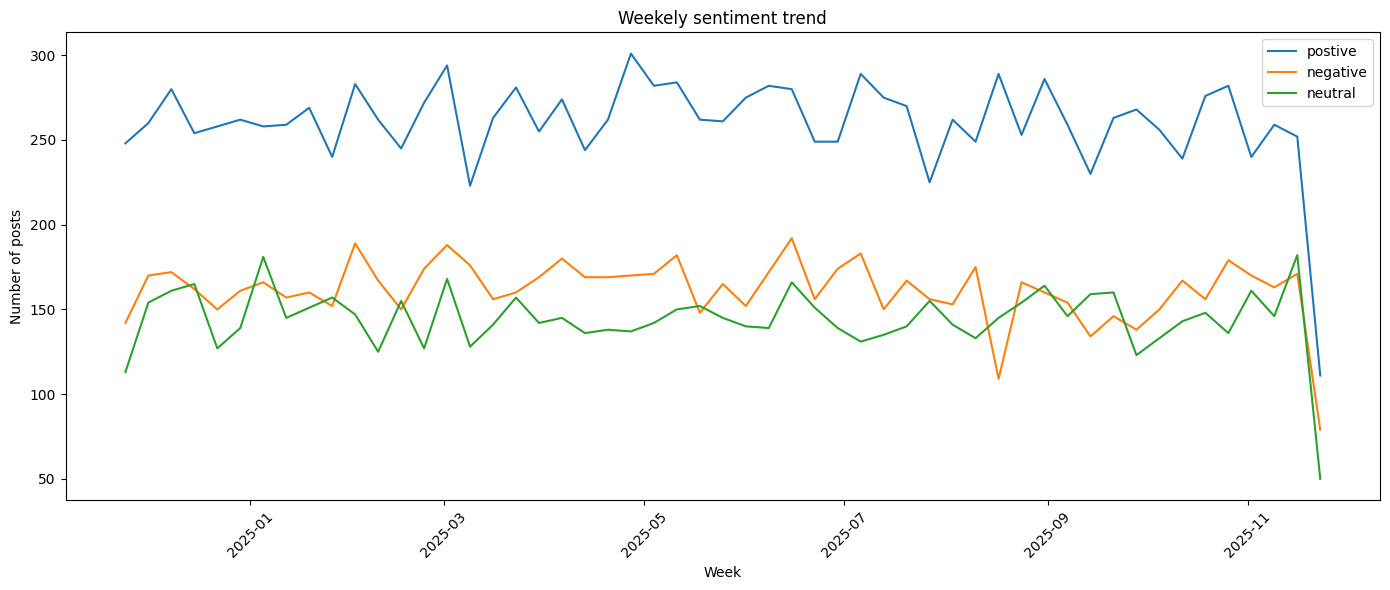

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    weekly_sentiment.index,
    weekly_sentiment["positive"],
    label="postive"
)
plt.plot(
    weekly_sentiment.index,
    weekly_sentiment["negative"],
    label="negative"
)
plt.plot(
    weekly_sentiment.index,
    weekly_sentiment["neutral"],
    label="neutral"
)
plt.xlabel("Week")
plt.ylabel("Number of posts")
plt.title("Weekely sentiment trend")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
weekly_percentage = weekly_sentiment.div(
    weekly_sentiment.sum(axis=1),
    axis=0
) * 100

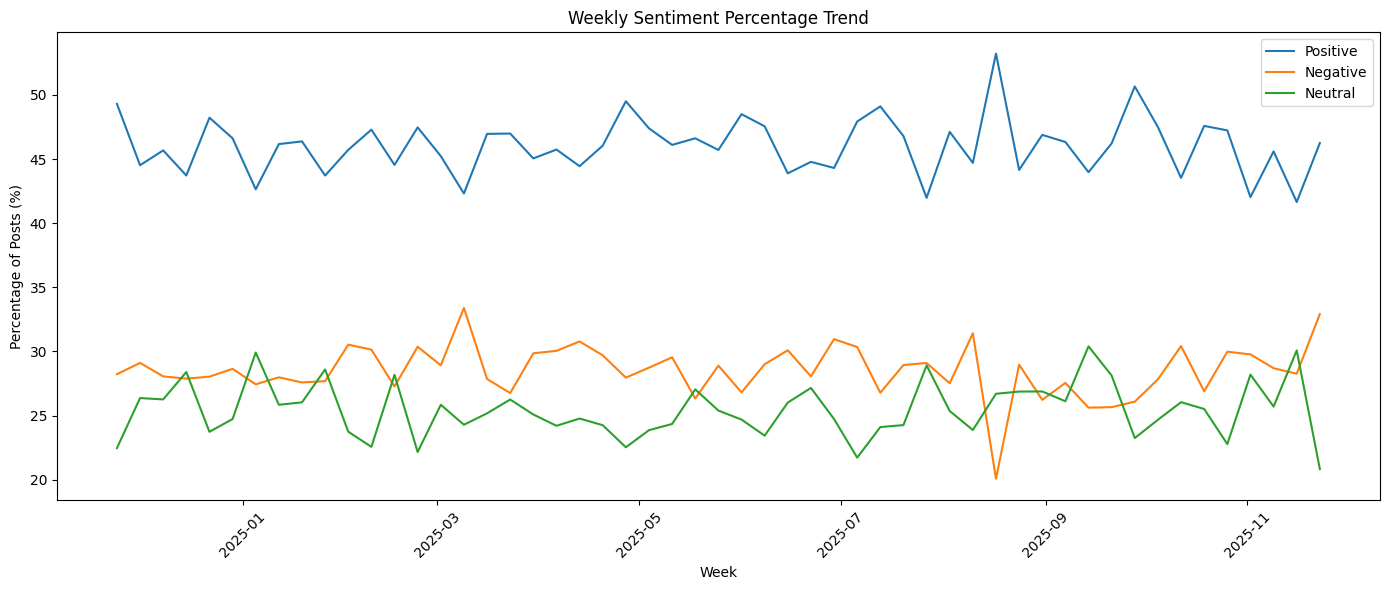

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    weekly_percentage.index,
    weekly_percentage["positive"],
    label="Positive"
)

plt.plot(
    weekly_percentage.index,
    weekly_percentage["negative"],
    label="Negative"
)

plt.plot(
    weekly_percentage.index,
    weekly_percentage["neutral"],
    label="Neutral"
)

plt.xlabel("Week")
plt.ylabel("Percentage of Posts (%)")
plt.title("Weekly Sentiment Percentage Trend")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
sentiment_engagement=df.groupby("sentiment")["shares"].mean()
print(sentiment_engagement)

sentiment
negative    14.493740
neutral     14.145659
positive    14.540713
Name: shares, dtype: float64


In [ ]:
sentiment_engagement_rate=df.groupby("sentiment")["engagement_rate"].mean()
print(sentiment_engagement_rate)

sentiment
negative    0.042120
neutral     0.041940
positive    0.042192
Name: engagement_rate, dtype: float64


In [ ]:
sentiment_reach=df.groupby("sentiment")["reach"].mean()
print(sentiment_reach)

sentiment
negative    6252.074646
neutral     6224.314854
positive    6311.789988
Name: reach, dtype: float64


In [ ]:
sentiment_analysis=df.groupby("sentiment").agg({
    "engagement_rate": "mean",
    "reach":"mean",
    "shares":"mean"
})
print(sentiment_analysis)


           engagement_rate        reach     shares
sentiment                                         
negative          0.042120  6252.074646  14.493740
neutral           0.041940  6224.314854  14.145659
positive          0.042192  6311.789988  14.540713


In [ ]:
negative_post=df[df["sentiment"]=="negative"].copy()
negative_post.shape

(8547, 26)

In [ ]:
share_thresold=negative_post["shares"].quantile(0.90)
print(share_thresold)

31.0


In [ ]:
high_share_negative=negative_post[
    negative_post["shares"]>=share_thresold
]
high_share_negative.shape

(897, 26)

In [ ]:
high_share_negative[[
    "shares",
    "caption",
    "engagement_rate",
    "followers_gained",
    "sentiment_score",
    "reach"

]].sort_values("shares",ascending=False).head(10)

,shares,caption,engagement_rate,followers_gained,sentiment_score,reach
29801,516,Food update: The result is extremely bad and l...,0.2398,690,-0.8655,46738
28355,441,Fashion update: I am extremely dissatisfied wi...,0.2421,577,-0.2006,33224
20346,207,"Today's topic: This experience was terrible, f...",0.1351,240,-0.7184,22877
20714,192,New tech idea: The result is extremely bad and...,0.0772,900,-0.8655,46871
25273,174,Fashion update: The result is extremely bad an...,0.1664,85,-0.8655,16526
21305,162,Technology update: This was awful and disappoi...,0.1549,725,-0.8516,12864
26938,156,Training routine: This is extremely disappoint...,0.0797,243,-0.7640,45587
26064,156,New look: This is extremely disappointing and ...,0.0759,225,-0.7640,39149
27131,140,Training routine: This experience was terrible...,0.0654,688,-0.7184,36716
21420,136,Photography post: This is a very poor result a...,0.0507,473,-0.8016,39194


In [ ]:
df["negative_score"] = (-df["sentiment_score"]).clip(0, 1)

In [ ]:
df["share_score"] = (
    df["shares"] / df["shares"].max()
)

In [ ]:
df["reach_score"] = (
    df["reach"] / df["reach"].max()
)

In [ ]:
df["share_score"] = df["shares"] / df["shares"].max()

df["reach_score"] = df["reach"] / df["reach"].max()

df["engagement_score"] = (
    df["engagement_rate"] / df["engagement_rate"].max()
)

In [ ]:
df[["share_score", "reach_score", "engagement_score"]].head()

,share_score,reach_score,engagement_score
0,0.013566,0.059000,0.142066
1,0.040698,0.101597,0.244649
2,0.001938,0.022348,0.195941
3,0.013566,0.039229,0.114022
4,0.009690,0.072949,0.081550


In [ ]:
df["risk_score"] = (
    0.30 * df["negative_score"] +
    0.25 * df["share_score"] +
    0.25 * df["reach_score"] +
    0.20 * df["engagement_score"]
) * 100

In [ ]:
def risk_level(score):
    if score >= 70:
        return "High"
    elif score >= 40:
        return "Medium"
    else:
        return "Low"

df["risk_level"] = df["risk_score"].apply(risk_level)

In [ ]:
df["risk_level"].value_counts()

,count
risk_level,
Low,29894
Medium,104
High,1


In [ ]:
top_risk_posts = df.sort_values(
    "risk_score",
    ascending=False
)

top_risk_posts[
    [
        "caption",
        "sentiment_score",
        "shares",
        "reach",
        "engagement_rate",
        "risk_score",
        "risk_level"
    ]
].head(10)

,caption,sentiment_score,shares,reach,engagement_rate,risk_score,risk_level
29801,Food update: The result is extremely bad and l...,-0.8655,516,46738,0.2398,84.594595,High
20714,New tech idea: The result is extremely bad and...,-0.8655,192,46871,0.0772,56.942258,Medium
28355,Fashion update: I am extremely dissatisfied wi...,-0.2006,441,33224,0.2421,56.576926,Medium
25790,Musical moment: The result is extremely bad an...,-0.8655,132,10367,0.2476,54.167343,Medium
13720,Captured moment: Here is some information abou...,0.0000,444,44915,0.2102,52.335292,Medium
25273,Fashion update: The result is extremely bad an...,-0.8655,174,16526,0.1664,52.309104,Medium
26938,Training routine: This is extremely disappoint...,-0.7640,156,45587,0.0797,51.899880,Medium
24728,Musical moment: The result is extremely bad an...,-0.8655,120,46889,0.0527,51.651904,Medium
25058,New look: This was awful and disappointing. I ...,-0.8516,111,10414,0.2132,50.210177,Medium
26064,New look: This is extremely disappointing and ...,-0.7640,156,39149,0.0759,49.424834,Medium


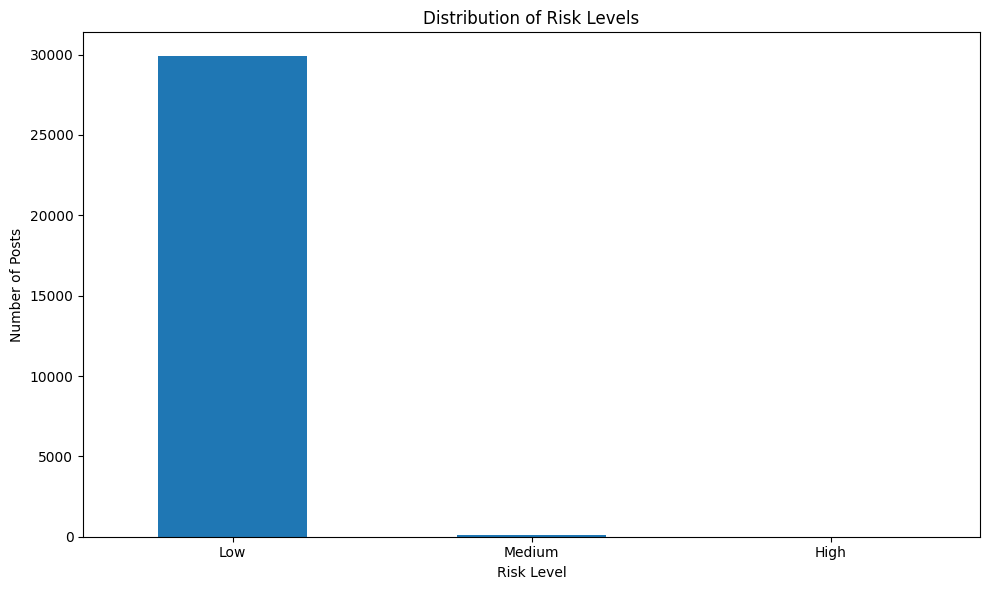

In [ ]:
plt.figure(figsize=(10, 6))

df["risk_level"].value_counts().plot(kind="bar")

plt.xlabel("Risk Level")
plt.ylabel("Number of Posts")
plt.title("Distribution of Risk Levels")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()